### Models:
In Langchain, "models" are the core interfaces through which you interact with AI models  
In Langchain, we can communicate with 2 type of models:  
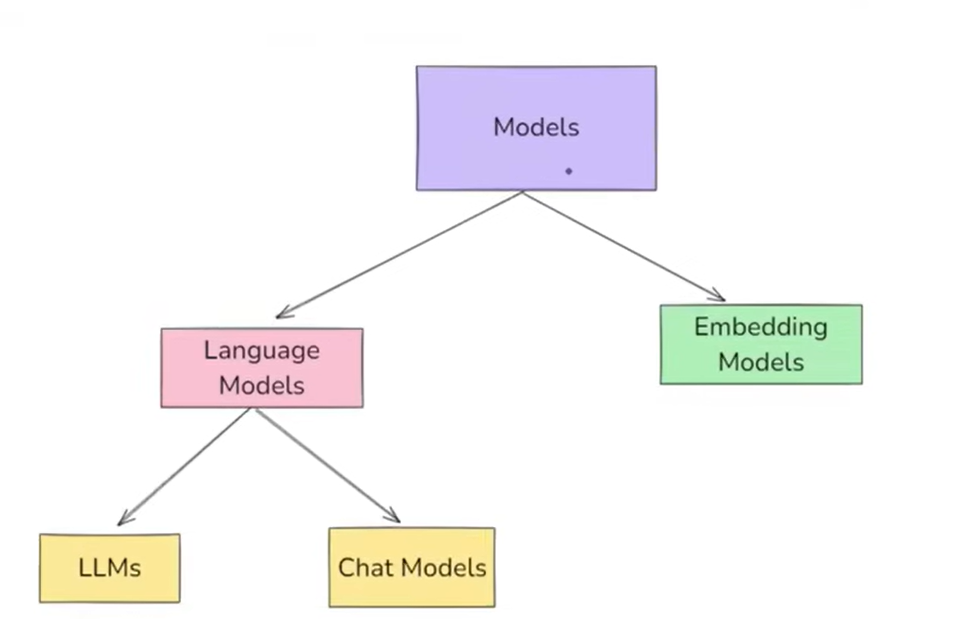
1. Language Models
    - LLMs:
        General-purpose models that is used for raw text generation. They take a string or plain text as input & returns a string. They are older models & are not used much now.  
    - Chat Models:
        Models that are specialized for conversational tasks. They take a sequence of messages as inputs  & returns chat messages as output.
    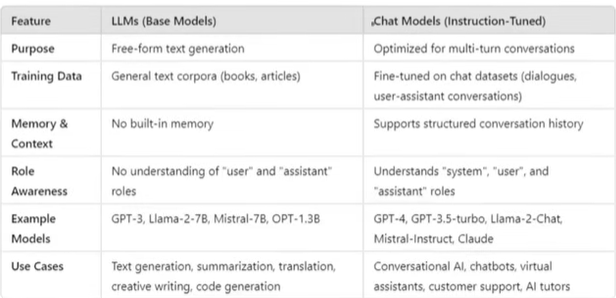

2. Embedding Models
    - These models takes text as a input & return vectors as a output

### LLM

In [1]:
# LLM - Input & Output both are Stings
from langchain_openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

llm = OpenAI(model='gpt-3.5-turbo-instruct')
# result = llm.invoke("What is the capital of India")
# Expected Answer: "The capital of India is New Delhi." --> Output is string

print(llm)

d:\Repos\Agents\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenAI
Params: {'model_name': 'gpt-3.5-turbo-instruct', 'temperature': 0.7, 'top_p': 1, 'frequency_penalty': 0, 'presence_penalty': 0, 'n': 1, 'seed': None, 'logprobs': None, 'max_tokens': 256}


### Chat Models
### Chat Model Parameters:  
1. Temperature: 
    - Parameter that controls the randomness of a LLM's output. It affects how creative or deterministic the responses are
        - Lower Values (0.0 - 0.3) - More deterministic & predictable
        - Higher Value (0.7 - 1.5) - More random, creative & diverse
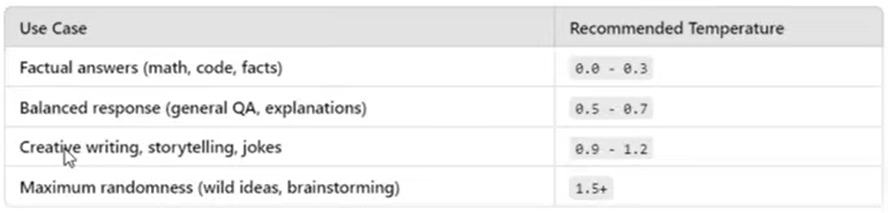

2. max_tokens / max_completion_tokens:
    - Maximum number of tokens the model can generate in the response
    - Prevents overly long outputs and controls cost


3. top_p (Nucleus Sampling)
    - Controls diversity by selecting from top probability tokens
    - Works as an alternative to temperature
        - Low (0.1–0.5): focused, safe
        - High (0.9–1.0): diverse output

- Tip: Usually adjust either temperature OR top_p, not both

4. frequency_penalty:
    - Penalizes repeated words/phrases
    - Helps reduce redundancy
        - 0.0: no penalty
        - greater than 0: less repetition

5. presence_penalty:
    - Encourages introducing new topics/words
    - Useful for creative writing
    - Higher value → more exploration

6. stop: Defines stop sequences where the model should stop generating
7. models: Specifies which models to use
8. streaming: Enables token by token output (real time response)
9. timeout: Max time allowed for a request
10. n: Number of responses to generate
11. seed: Ensures reproducible outputs (same input - same output)

In [2]:
# Open AI - Input can be string or list of messages, Output is a response object containing generated text
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI(model='gpt-5.4', temperature=1.5, max_completion_tokens=10)
# result = model.invoke("Write a 5 line poem on cricket")
# Expected Output: Is a object containing the generated text and other metadata like tokens used, time taken, etc.

print(model)

profile={'name': 'GPT-5.4', 'release_date': '2026-03-05', 'last_updated': '2026-03-05', 'open_weights': False, 'max_input_tokens': 1050000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True} client=<openai.resources.chat.completions.completions.Completions object at 0x00000280856540E0> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000028085654110> root_client=<openai.OpenAI object at 0x0000028085542BA0> root_async_client=<openai.AsyncOpenAI object at 0x0000028085654050> model_name='gpt-5.4' model_kwargs={} openai_api_key=SecretStr('**********') stream

In [3]:
# Anthropic - Input can be string or list of messages, Output is a response object containing generated text
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv()

model = ChatAnthropic(model='claude-3-5-sonnet-20241022')
# result = model.invoke('What is the capital of India')
# Expected Output: Is a object containing the generated text and other metadata like tokens used, time taken, etc.

print(model)

profile={'name': 'Claude Sonnet 3.5 v2', 'release_date': '2024-10-22', 'last_updated': '2024-10-22', 'open_weights': False, 'max_input_tokens': 200000, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': False} model='claude-3-5-sonnet-20241022' max_tokens=8192 anthropic_api_url='https://api.anthropic.com' anthropic_api_key=SecretStr('**********') model_kwargs={}


In [4]:
# Google Gemini - Input can be string or list of messages, Output is a response object containing generated text
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')
result = model.invoke('What is the capital of India')
# Expected Result: content=[{'type': 'text', 'text': '...', 'extras': {'signature': ''}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 7, 'output_tokens': 40, 'total_tokens': 47, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 31}}

print("Raw Result:", result)
print("--" * 20)
print("Generated Text:", result.content[0]['text'])

Raw Result: content=[{'type': 'text', 'text': 'The capital of India is **New Delhi**.', 'extras': {'signature': 'EqEBCp4BAb4+9vszG6z7fhQ6B8pgClQz8iK1GRp4PFIT0lfWXwti6vEywQy4xX4uu08YweoR5+PYaflo8NOpqL406rdOLV1Y4DFm9voW3O5nPEr68KwcRm/sxPYuEC1tQawWfPWavtI8ormVbPRNCb1guQ7JDOv2CUAP+ONGBPyRkYjWayFyGLOs/H0epiA7yY9nBFzDq5fkDQ4rg/lAT3jvPpE='}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d8bfe-9db7-7ad1-bf84-5769f39358cc-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 7, 'output_tokens': 40, 'total_tokens': 47, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 31}}
----------------------------------------
Generated Text: The capital of India is **New Delhi**.


### Embedding Models

In [5]:
# OpenAI Embeddings - Input is a string, Output is a list of floats representing the embedding vector
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=32)

# result = embedding.embed_query("Delhi is the capital of India")

print(embedding)

client=<openai.resources.embeddings.Embeddings object at 0x000002808901DC40> async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000002808901DC70> model='text-embedding-3-large' dimensions=32 deployment='text-embedding-ada-002' openai_api_version=None openai_api_base=None openai_api_type=None openai_proxy=None embedding_ctx_length=8191 openai_api_key=SecretStr('**********') openai_organization=None allowed_special=None disallowed_special=None chunk_size=1000 max_retries=2 request_timeout=None headers=None tiktoken_enabled=True tiktoken_model_name=None show_progress_bar=False model_kwargs={} skip_empty=False default_headers=None default_query=None retry_min_seconds=4 retry_max_seconds=20 http_client=None http_async_client=None check_embedding_ctx_length=True


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings

# CORRECT model name (single 'L')
embedding = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

documents = [
    "Delhi is the capital of India",
    "Kolkata is the capital of West Bengal",
    "Paris is the capital of France"
]

vector = embedding.embed_documents(documents)
print(f"Successfully embedded {len(vector)} documents")
print(f"Embedding dimension: {len(vector[0])}")
print(f"First 5 values of first embedding: {vector[0][:5]}")

Successfully embedded 3 documents
Embedding dimension: 384
First 5 values of first embedding: [0.043549567461013794, 0.02387724071741104, -0.045241255313158035, 0.035404980182647705, -0.01665104553103447]


In [7]:
# Cosine Similarity between query embedding and document embeddings to find the most relevant document
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

load_dotenv()

embedding = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
documents = [
    "Virat Kohli is an Indian cricketer known for his aggressive batting and leadership.",
    "MS Dhoni is a former Indian captain famous for his calm demeanor and finishing skills.",
    "Sachin Tendulkar, also known as the 'God of Cricket', holds many batting records.",
    "Rohit Sharma is known for his elegant batting and record-breaking double centuries.",
    "Jasprit Bumrah is an Indian fast bowler known for his unorthodox action and yorkers."
]

query = 'tell me about bumrah'
doc_embeddings = embedding.embed_documents(documents)
query_embedding = embedding.embed_query(query)

scores = cosine_similarity([query_embedding], doc_embeddings)[0]
index, score = sorted(list(enumerate(scores)),key=lambda x:x[1])[-1]

print(query)
print(documents[index])
print("similarity score is:", score)

tell me about bumrah
Jasprit Bumrah is an Indian fast bowler known for his unorthodox action and yorkers.
similarity score is: 0.6183837601900769
